## 1. Import libraries and API dataset

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from numpy import random
import time
import sys
sys.path.append('/Users/esthervanhelmont/Documents/Tomorrow University/ICS 6 Data Structures')
from oecd_api import OECDAPIClient

## 2. Quick check loaded data

In [2]:
# OECD API Client
client = OECDAPIClient()

# Select multiple countries to create a larger dataset
country_codes = [
    "NLD", "BEL", "DEU", "FRA", "ESP",
    "ITA", "DNK", "SWE", "NOR", "FIN"
]

# Create an empty list for the women's data
women_dataframes = []

print("Loading data for women from multiple countries...")

# Load the data for every country
for country_code in country_codes:
    try:
        country_data = client.get_filtered_data(
            country=country_code,
            gender="WOMEN",
            age_group="25-54",
            start_year="2010",
            end_year="2023"
        )

        women_dataframes.append(country_data)

    except Exception as error:
        print(f"Could not load {country_code}: {error}")

# Combine all countries into one DataFrame
nl_women = pd.concat(
    women_dataframes,
    ignore_index=True
)

print(f"Number of original rows: {len(nl_women)}")
print(nl_women.head())


Loading data for women from multiple countries...
Number of original rows: 3266
                  DATAFLOW  COU     IND    SEX   AGE     TIME  OBS_VALUE  \
0  OECD:DF_GENDER_EMP(1.0)  NLD  EMP4_E  WOMEN  2554  Q4-2016       78.5   
1  OECD:DF_GENDER_EMP(1.0)  NLD  EMP4_E  WOMEN  2554  Q2-2019       81.5   
2  OECD:DF_GENDER_EMP(1.0)  NLD  EMP4_E  WOMEN  2554  Q1-2016       77.4   
3  OECD:DF_GENDER_EMP(1.0)  NLD  EMP4_E  WOMEN  2554  Q3-2008       78.6   
4  OECD:DF_GENDER_EMP(1.0)  NLD  EMP4_E  WOMEN  2554  Q2-2011       78.4   

  OBS_STATUS UNIT_MEASURE  UNIT_MULT  BASE_PER  
0          A           PC          0       NaN  
1          A           PC          0       NaN  
2          A           PC          0       NaN  
3          A           PC          0       NaN  
4          A           PC          0       NaN  


# Milestone 3
## 3. Prepare the data

Before sorting the data, we need to clean it.

In this step, we:

- combine data from multiple countries;
- use the same age group for all records;
- keep only one indicator;
- keep only percentage values;
- use quarterly data from 2010 to 2023;
- remove empty or invalid rows;
- reset the row numbers.

Using one indicator and one unit makes the values comparable.

After this step, the dataset is ready to use for the sorting algorithms.


In [3]:
# Create a copy so the original dataset remains unchanged
nl_women_clean = nl_women.copy()

# Extract the year from values such as "Q4-2022"
nl_women_clean["YEAR"] = (
    nl_women_clean["TIME"]
    .astype(str)
    .str.extract(r"(\d{4})")
    .astype("Int64")
)

# Make sure OBS_VALUE is stored as a numerical value
nl_women_clean["OBS_VALUE"] = pd.to_numeric(
    nl_women_clean["OBS_VALUE"],
    errors="coerce"
)

# Remove rows without a valid year or observation value
nl_women_clean = nl_women_clean.dropna(
    subset=["YEAR", "OBS_VALUE"]
)

# Keep one indicator so all values measure the same thing
nl_women_clean = nl_women_clean[
    nl_women_clean["IND"] == "EMP4_E"
]

# Keep only percentage values
nl_women_clean = nl_women_clean[
    nl_women_clean["UNIT_MEASURE"] == "PC"
]

# Keep only quarterly records
nl_women_clean = nl_women_clean[
    nl_women_clean["TIME"]
    .astype(str)
    .str.match(r"Q[1-4]-\d{4}", na=False)
]

# Keep only data from 2010 up to and including 2023
nl_women_clean = nl_women_clean[
    nl_women_clean["YEAR"].between(2010, 2023)
]

# Reset the index to 0, 1, 2, 3...
nl_women_clean = nl_women_clean.reset_index(drop=True)

print(f"Number of usable rows: {len(nl_women_clean)}")
print(f"Number of countries: {nl_women_clean['COU'].nunique()}")
print(f"Years in the dataset: {sorted(nl_women_clean['YEAR'].unique())}")
print(f"Indicator used: {nl_women_clean['IND'].unique().tolist()}")

nl_women_clean[
    [
        "COU", "IND", "SEX", "AGE",
        "TIME", "YEAR", "OBS_VALUE"
    ]
].head(10)


Number of usable rows: 540
Number of countries: 10
Years in the dataset: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Indicator used: ['EMP4_E']


,COU,IND,SEX,AGE,TIME,YEAR,OBS_VALUE
0,NLD,EMP4_E,WOMEN,2554,Q4-2016,2016,78.5
1,NLD,EMP4_E,WOMEN,2554,Q2-2019,2019,81.5
2,NLD,EMP4_E,WOMEN,2554,Q1-2016,2016,77.4
3,NLD,EMP4_E,WOMEN,2554,Q2-2011,2011,78.4
4,NLD,EMP4_E,WOMEN,2554,Q2-2014,2014,76.7
5,NLD,EMP4_E,WOMEN,2554,Q2-2021,2021,81.8
6,NLD,EMP4_E,WOMEN,2554,Q3-2011,2011,78.1
7,NLD,EMP4_E,WOMEN,2554,Q1-2010,2010,78.4
8,NLD,EMP4_E,WOMEN,2554,Q4-2015,2015,77.3
9,NLD,EMP4_E,WOMEN,2554,Q1-2020,2020,81.9


## 4. Convert the data into a list

A sorting algorithm works with a list of items.

In this step, we convert the cleaned DataFrame into a list of records.

Each record contains all information from one row. This means that the year, age group and observation value stay together when we sort the data.

Later, we will sort these records based on `OBS_VALUE`.

In [4]:
# Convert the DataFrame into a list of records
women_records = nl_women_clean.to_dict(orient="records")

# Show the number of records
print(f"Number of records: {len(women_records)}")

# Show the first three records
for record in women_records[:3]:
    print(record)

Number of records: 540
{'DATAFLOW': 'OECD:DF_GENDER_EMP(1.0)', 'COU': 'NLD', 'IND': 'EMP4_E', 'SEX': 'WOMEN', 'AGE': '2554', 'TIME': 'Q4-2016', 'OBS_VALUE': 78.5, 'OBS_STATUS': 'A', 'UNIT_MEASURE': 'PC', 'UNIT_MULT': 0, 'BASE_PER': nan, 'YEAR': 2016}
{'DATAFLOW': 'OECD:DF_GENDER_EMP(1.0)', 'COU': 'NLD', 'IND': 'EMP4_E', 'SEX': 'WOMEN', 'AGE': '2554', 'TIME': 'Q2-2019', 'OBS_VALUE': 81.5, 'OBS_STATUS': 'A', 'UNIT_MEASURE': 'PC', 'UNIT_MULT': 0, 'BASE_PER': nan, 'YEAR': 2019}
{'DATAFLOW': 'OECD:DF_GENDER_EMP(1.0)', 'COU': 'NLD', 'IND': 'EMP4_E', 'SEX': 'WOMEN', 'AGE': '2554', 'TIME': 'Q1-2016', 'OBS_VALUE': 77.4, 'OBS_STATUS': 'A', 'UNIT_MEASURE': 'PC', 'UNIT_MULT': 0, 'BASE_PER': nan, 'YEAR': 2016}


## 5. Sort the data with Bubble Sort

Bubble Sort compares two records next to each other.

If the first value is higher than the second value, the records switch places.

This process repeats until all records are sorted from the lowest to the highest `OBS_VALUE`.

We create a copy of the list so the original data does not change.

In [5]:
def bubble_sort(records, key):
    # Create a copy so the original list remains unchanged
    sorted_records = records.copy()

    # Store the number of records
    number_of_records = len(sorted_records)

    # Repeat the sorting process
    for i in range(number_of_records):

        # Keep track of whether two records changed places
        swapped = False

        # Compare two records next to each other
        for j in range(0, number_of_records - i - 1):

            # Switch the records if the first value is higher
            if sorted_records[j][key] > sorted_records[j + 1][key]:
                sorted_records[j], sorted_records[j + 1] = (
                    sorted_records[j + 1],
                    sorted_records[j]
                )

                swapped = True

        # Stop early if no records changed places
        if not swapped:
            break

    return sorted_records

ITA Q2-2014 57.2
ITA Q3-2013 57.4
ITA Q3-2014 57.4
ITA Q4-2013 57.5
ITA Q2-2013 57.5
ITA Q2-2020 57.6
ITA Q2-2015 57.6
ITA Q1-2014 57.6
ITA Q4-2014 57.6
ITA Q1-2015 57.8


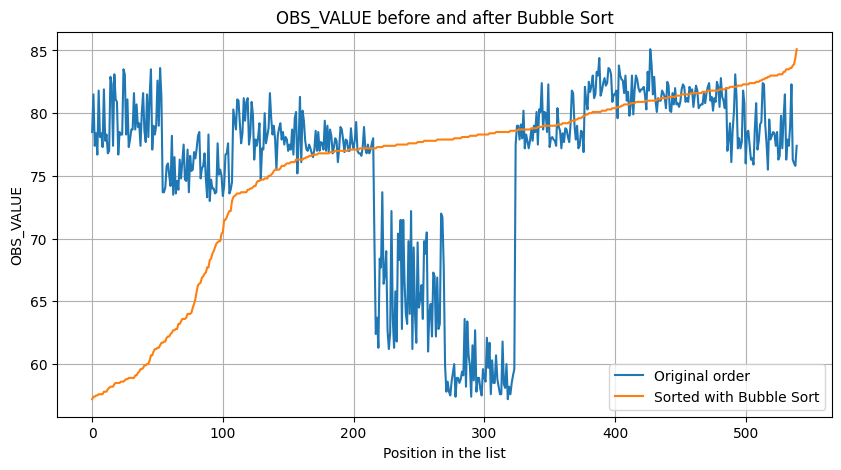

In [6]:
# Sort the records based on OBS_VALUE
bubble_sorted_women = bubble_sort(
    women_records,
    key="OBS_VALUE"
)

# Show the first ten sorted records
for record in bubble_sorted_women[:10]:
    print(record["COU"], record["TIME"], record["OBS_VALUE"])

    import matplotlib.pyplot as plt

# Get the OBS_VALUE values from the original records
original_values = [
    record["OBS_VALUE"] for record in women_records
]

# Get the OBS_VALUE values from the sorted records
bubble_sorted_values = [
    record["OBS_VALUE"] for record in bubble_sorted_women
]

# Create the visualization
plt.figure(figsize=(10, 5))

plt.plot(
    original_values,
    label="Original order"
)

plt.plot(
    bubble_sorted_values,
    label="Sorted with Bubble Sort"
)

# Add a title and labels
plt.title("OBS_VALUE before and after Bubble Sort")
plt.xlabel("Position in the list")
plt.ylabel("OBS_VALUE")

# Show the legend and graph
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

The Bubble Sort algorithm worked correctly.

Before sorting, the `OBS_VALUE` values are in their original order.

After using Bubble Sort, the values are ordered from the lowest to the highest.

The first results also confirm that the values increase.

This means that Bubble Sort successfully sorted the complete records based on `OBS_VALUE`, while keeping information such as the country and time connected to the correct value.


## 5.1 Measure the performance of Bubble Sort

The sorting algorithm works correctly, but we also want to know how fast it is.

In this step, we measure the execution time of Bubble Sort.

The timer starts before the algorithm runs and stops after the sorting is complete. The result is converted from seconds to milliseconds.

We also check whether all values are sorted correctly from low to high.

In [7]:
import time

# Start the timer
start_time = time.perf_counter()

# Sort the records with Bubble Sort
bubble_sorted_women = bubble_sort(
    women_records,
    key="OBS_VALUE"
)

# Stop the timer
end_time = time.perf_counter()

# Convert the execution time from seconds to milliseconds
bubble_time_ms = (end_time - start_time) * 1000

# Check whether all OBS_VALUE values are sorted correctly
bubble_sort_correct = all(
    bubble_sorted_women[i]["OBS_VALUE"]
    <= bubble_sorted_women[i + 1]["OBS_VALUE"]
    for i in range(len(bubble_sorted_women) - 1)
)

print(f"Number of records: {len(women_records)}")
print(f"Bubble Sort execution time: {bubble_time_ms:.6f} milliseconds")
print(f"Correctly sorted: {bubble_sort_correct}")

Number of records: 540
Bubble Sort execution time: 6.152458 milliseconds
Correctly sorted: True


## 6. Sort the data with Merge Sort

Merge Sort uses a different method than Bubble Sort.

First, it divides the list into smaller parts. It continues until every part contains only one record.

After this, the smaller parts are combined again in the correct order.

Merge Sort is usually faster than Bubble Sort when the dataset becomes larger.

In [8]:
def merge_sort(records, key):
    # Return the list when it contains zero or one record
    if len(records) <= 1:
        return records.copy()

    # Find the middle of the list
    middle = len(records) // 2

    # Divide the list into a left and right part
    left_part = records[:middle]
    right_part = records[middle:]

    # Sort both parts
    sorted_left = merge_sort(left_part, key)
    sorted_right = merge_sort(right_part, key)

    # Create an empty list for the combined result
    merged_records = []

    left_index = 0
    right_index = 0

    # Compare records from both parts
    while (
        left_index < len(sorted_left)
        and right_index < len(sorted_right)
    ):
        if (
            sorted_left[left_index][key]
            <= sorted_right[right_index][key]
        ):
            merged_records.append(
                sorted_left[left_index]
            )
            left_index += 1
        else:
            merged_records.append(
                sorted_right[right_index]
            )
            right_index += 1

    # Add records that are still left
    merged_records.extend(
        sorted_left[left_index:]
    )

    merged_records.extend(
        sorted_right[right_index:]
    )

    return merged_records

Number of records: 540
Merge Sort execution time: 0.406292 milliseconds
Correctly sorted: True
ITA Q2-2014 57.2
ITA Q3-2013 57.4
ITA Q3-2014 57.4
ITA Q4-2013 57.5
ITA Q2-2013 57.5
ITA Q2-2020 57.6
ITA Q2-2015 57.6
ITA Q1-2014 57.6
ITA Q4-2014 57.6
ITA Q1-2015 57.8


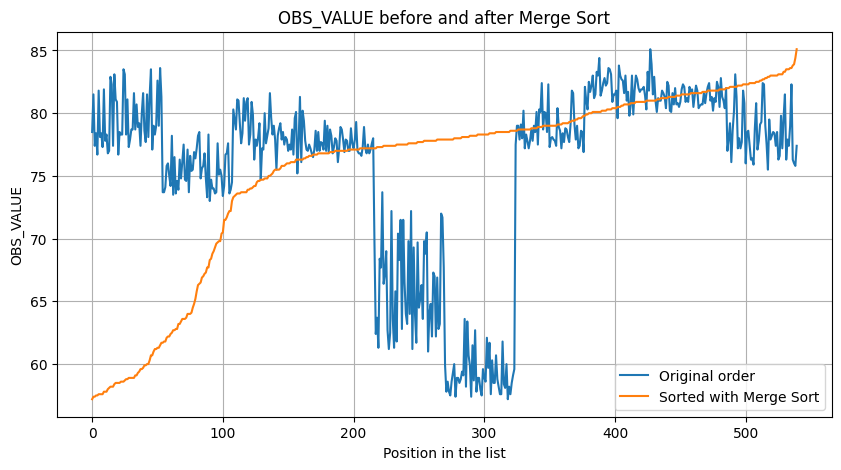

In [9]:
# Start the timer
start_time = time.perf_counter()

# Sort the records with Merge Sort
merge_sorted_women = merge_sort(
    women_records,
    key="OBS_VALUE"
)

# Stop the timer
end_time = time.perf_counter()

# Convert the execution time to milliseconds
merge_time_ms = (end_time - start_time) * 1000

# Check whether the values are sorted correctly
merge_sort_correct = all(
    merge_sorted_women[i]["OBS_VALUE"]
    <= merge_sorted_women[i + 1]["OBS_VALUE"]
    for i in range(len(merge_sorted_women) - 1)
)

print(f"Number of records: {len(women_records)}")
print(
    f"Merge Sort execution time: "
    f"{merge_time_ms:.6f} milliseconds"
)
print(f"Correctly sorted: {merge_sort_correct}")

# Show the first ten sorted records
for record in merge_sorted_women[:10]:
    print(record["COU"], record["TIME"], record["OBS_VALUE"])

import matplotlib.pyplot as plt

# Get the OBS_VALUE values from the original records
original_values = [
    record["OBS_VALUE"] for record in women_records
]

# Get the OBS_VALUE values from the Merge Sort result
merge_sorted_values = [
    record["OBS_VALUE"] for record in merge_sorted_women
]

# Create the graph
plt.figure(figsize=(10, 5))

# Show the values in their original order
plt.plot(
    original_values,
    label="Original order"
)

# Show the values after Merge Sort
plt.plot(
    merge_sorted_values,
    label="Sorted with Merge Sort"
)

# Add a title and axis labels
plt.title("OBS_VALUE before and after Merge Sort")
plt.xlabel("Position in the list")
plt.ylabel("OBS_VALUE")

# Show the legend and grid
plt.legend()
plt.grid(True)

# Display the graph
plt.show()

## Conclusion

Merge Sort worked correctly.

The result `Correctly sorted: True` shows that all records are in the correct order.

The graph also confirms this. The original values move up and down, while the Merge Sort line moves from the lowest value to the highest value.

The final order is the same as with Bubble Sort, but Merge Sort uses a different and more efficient method.

The exact execution time is shown in the output above.


## 7. Compare the performance of both algorithms

Both algorithms sorted the data correctly.

Now we compare their execution times.

Because the dataset is small, one measurement may not be reliable. Therefore, each algorithm is executed 100 times.

We calculate the average execution time in milliseconds. This gives us a more stable comparison between Bubble Sort and Merge Sort.

In [10]:
def measure_average_time(
    sorting_algorithm,
    records,
    key,
    repetitions=100
):
    # Store the total execution time
    total_time = 0

    # Run the sorting algorithm multiple times
    for _ in range(repetitions):
        start_time = time.perf_counter()

        sorting_algorithm(
            records,
            key
        )

        end_time = time.perf_counter()

        total_time += end_time - start_time

    # Calculate the average time in milliseconds
    average_time_ms = (
        total_time / repetitions
    ) * 1000

    return average_time_ms


# Measure the average execution time of Bubble Sort
bubble_average_ms = measure_average_time(
    bubble_sort,
    women_records,
    key="OBS_VALUE"
)

# Measure the average execution time of Merge Sort
merge_average_ms = measure_average_time(
    merge_sort,
    women_records,
    key="OBS_VALUE"
)

print(
    f"Bubble Sort average time: "
    f"{bubble_average_ms:.6f} milliseconds"
)

print(
    f"Merge Sort average time: "
    f"{merge_average_ms:.6f} milliseconds"
)

Bubble Sort average time: 6.111907 milliseconds
Merge Sort average time: 0.362475 milliseconds


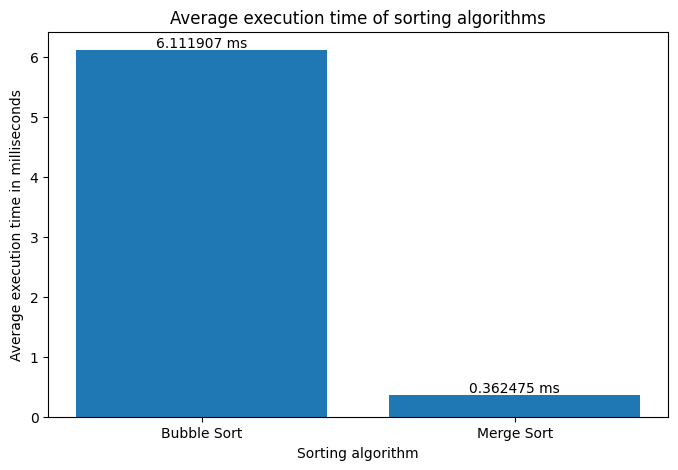

In [11]:
# Store the algorithm names and execution times
algorithm_names = [
    "Bubble Sort",
    "Merge Sort"
]

average_times = [
    bubble_average_ms,
    merge_average_ms
]

# Create the bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    algorithm_names,
    average_times
)

# Add a title and axis labels
plt.title("Average execution time of sorting algorithms")
plt.xlabel("Sorting algorithm")
plt.ylabel("Average execution time in milliseconds")

# Show the value above each bar
for bar, execution_time in zip(
    bars,
    average_times
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{execution_time:.6f} ms",
        ha="center",
        va="bottom"
    )

plt.show()

## Conclusion

Both algorithms sorted the data correctly.

The output and graph show which algorithm had the lowest average execution time.

A lower execution time means that the algorithm completed the sorting task faster.

The comparison uses a larger dataset with one indicator, one unit and the same period for all records. This makes the performance test more useful.


## 8. Load a second dataset

So far, we have used a dataset about women from multiple countries.

To test the sorting algorithms on a second dataset, we now load data about men from the same countries.

We use the same age group, indicator, unit and years. This makes the two datasets comparable.


In [12]:
# Create an empty list for the men's data
men_dataframes = []

print("Loading data for men from multiple countries...")

# Load the data for every country
for country_code in country_codes:
    try:
        country_data = client.get_filtered_data(
            country=country_code,
            gender="MEN",
            age_group="25-54",
            start_year="2010",
            end_year="2023"
        )

        men_dataframes.append(country_data)

    except Exception as error:
        print(f"Could not load {country_code}: {error}")

# Combine all countries into one DataFrame
nl_men = pd.concat(
    men_dataframes,
    ignore_index=True
)

print(f"Number of original rows: {len(nl_men)}")
print(nl_men.head())


Loading data for men from multiple countries...
Number of original rows: 3266
                  DATAFLOW  COU     IND  SEX   AGE     TIME  OBS_VALUE  \
0  OECD:DF_GENDER_EMP(1.0)  NLD  EMP4_E  MEN  2554  Q2-2022       90.5   
1  OECD:DF_GENDER_EMP(1.0)  NLD  EMP4_E  MEN  2554  Q4-2015       88.0   
2  OECD:DF_GENDER_EMP(1.0)  NLD  EMP4_E  MEN  2554  Q1-2017       88.4   
3  OECD:DF_GENDER_EMP(1.0)  NLD  EMP4_E  MEN  2554  Q4-2022       90.5   
4  OECD:DF_GENDER_EMP(1.0)  NLD  EMP4_E  MEN  2554  Q4-2009       91.2   

  OBS_STATUS UNIT_MEASURE  UNIT_MULT  BASE_PER  
0          A           PC          0       NaN  
1          A           PC          0       NaN  
2          A           PC          0       NaN  
3          A           PC          0       NaN  
4          A           PC          0       NaN  


In [13]:
# Create a copy so the original dataset remains unchanged
nl_men_clean = nl_men.copy()

# Extract the year from values such as "Q4-2022"
nl_men_clean["YEAR"] = (
    nl_men_clean["TIME"]
    .astype(str)
    .str.extract(r"(\d{4})")
    .astype("Int64")
)

# Make sure OBS_VALUE is stored as a numerical value
nl_men_clean["OBS_VALUE"] = pd.to_numeric(
    nl_men_clean["OBS_VALUE"],
    errors="coerce"
)

# Remove rows without a valid year or observation value
nl_men_clean = nl_men_clean.dropna(
    subset=["YEAR", "OBS_VALUE"]
)

# Keep the same indicator as in the women's dataset
nl_men_clean = nl_men_clean[
    nl_men_clean["IND"] == "EMP4_E"
]

# Keep only percentage values
nl_men_clean = nl_men_clean[
    nl_men_clean["UNIT_MEASURE"] == "PC"
]

# Keep only quarterly records
nl_men_clean = nl_men_clean[
    nl_men_clean["TIME"]
    .astype(str)
    .str.match(r"Q[1-4]-\d{4}", na=False)
]

# Keep only data from 2010 up to and including 2023
nl_men_clean = nl_men_clean[
    nl_men_clean["YEAR"].between(2010, 2023)
]

# Reset the row numbers
nl_men_clean = nl_men_clean.reset_index(drop=True)

print(f"Number of usable rows: {len(nl_men_clean)}")
print(f"Number of countries: {nl_men_clean['COU'].nunique()}")
print(f"Years in the dataset: {sorted(nl_men_clean['YEAR'].unique())}")
print(f"Indicator used: {nl_men_clean['IND'].unique().tolist()}")

nl_men_clean[
    [
        "COU", "IND", "SEX", "AGE",
        "TIME", "YEAR", "OBS_VALUE"
    ]
].head(10)


Number of usable rows: 540
Number of countries: 10
Years in the dataset: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Indicator used: ['EMP4_E']


,COU,IND,SEX,AGE,TIME,YEAR,OBS_VALUE
0,NLD,EMP4_E,MEN,2554,Q2-2022,2022,90.5
1,NLD,EMP4_E,MEN,2554,Q4-2015,2015,88.0
2,NLD,EMP4_E,MEN,2554,Q1-2017,2017,88.4
3,NLD,EMP4_E,MEN,2554,Q4-2022,2022,90.5
4,NLD,EMP4_E,MEN,2554,Q2-2021,2021,89.7
5,NLD,EMP4_E,MEN,2554,Q2-2013,2013,87.1
6,NLD,EMP4_E,MEN,2554,Q2-2011,2011,89.6
7,NLD,EMP4_E,MEN,2554,Q1-2011,2011,90.2
8,NLD,EMP4_E,MEN,2554,Q1-2022,2022,90.4
9,NLD,EMP4_E,MEN,2554,Q3-2014,2014,87.0


In [14]:
# Convert the cleaned DataFrame into a list of records
men_records = nl_men_clean.to_dict(orient="records")

print(f"Number of records: {len(men_records)}")

# Show the first three records
for record in men_records[:3]:
    print(record)

Number of records: 540
{'DATAFLOW': 'OECD:DF_GENDER_EMP(1.0)', 'COU': 'NLD', 'IND': 'EMP4_E', 'SEX': 'MEN', 'AGE': '2554', 'TIME': 'Q2-2022', 'OBS_VALUE': 90.5, 'OBS_STATUS': 'A', 'UNIT_MEASURE': 'PC', 'UNIT_MULT': 0, 'BASE_PER': nan, 'YEAR': 2022}
{'DATAFLOW': 'OECD:DF_GENDER_EMP(1.0)', 'COU': 'NLD', 'IND': 'EMP4_E', 'SEX': 'MEN', 'AGE': '2554', 'TIME': 'Q4-2015', 'OBS_VALUE': 88.0, 'OBS_STATUS': 'A', 'UNIT_MEASURE': 'PC', 'UNIT_MULT': 0, 'BASE_PER': nan, 'YEAR': 2015}
{'DATAFLOW': 'OECD:DF_GENDER_EMP(1.0)', 'COU': 'NLD', 'IND': 'EMP4_E', 'SEX': 'MEN', 'AGE': '2554', 'TIME': 'Q1-2017', 'OBS_VALUE': 88.4, 'OBS_STATUS': 'A', 'UNIT_MEASURE': 'PC', 'UNIT_MULT': 0, 'BASE_PER': nan, 'YEAR': 2017}


## 9. Test both algorithms on the second dataset

In this step, we test Bubble Sort and Merge Sort on the dataset about men.

Both algorithms sort the records based on `OBS_VALUE`.

We run each algorithm 100 times to calculate a more reliable average execution time.

We also check if both algorithms sorted the data correctly and compare their performance in a bar chart.

Number of records: 540

Bubble Sort average time: 6.720630 milliseconds
Bubble Sort correctly sorted: True

Merge Sort average time: 0.352187 milliseconds
Merge Sort correctly sorted: True

First ten sorted records:
ESP Q2-2013 70.1
ESP Q3-2013 70.3
ESP Q1-2013 70.4
ESP Q4-2012 70.4
ESP Q3-2012 70.8
ESP Q4-2013 71.0
ESP Q1-2014 71.2
ESP Q2-2012 71.4
ESP Q2-2014 72.2
ESP Q1-2012 72.5


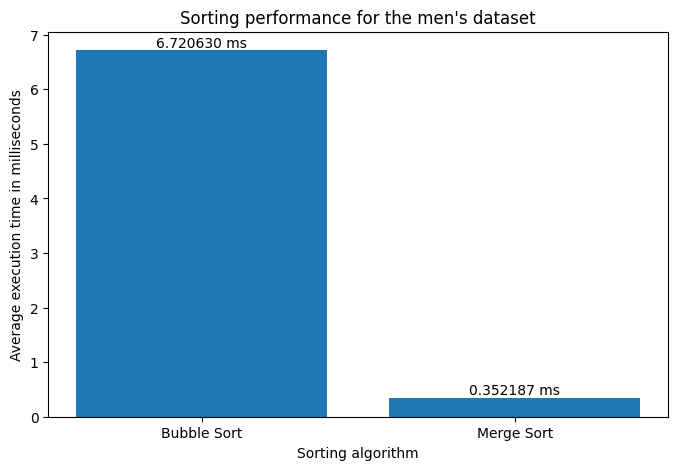

In [15]:
# Sort the second dataset with both algorithms
bubble_sorted_men = bubble_sort(
    men_records,
    key="OBS_VALUE"
)

merge_sorted_men = merge_sort(
    men_records,
    key="OBS_VALUE"
)

# Check whether both results are sorted correctly
bubble_men_correct = all(
    bubble_sorted_men[i]["OBS_VALUE"]
    <= bubble_sorted_men[i + 1]["OBS_VALUE"]
    for i in range(len(bubble_sorted_men) - 1)
)

merge_men_correct = all(
    merge_sorted_men[i]["OBS_VALUE"]
    <= merge_sorted_men[i + 1]["OBS_VALUE"]
    for i in range(len(merge_sorted_men) - 1)
)

# Measure the average execution time of both algorithms
bubble_men_average_ms = measure_average_time(
    bubble_sort,
    men_records,
    key="OBS_VALUE",
    repetitions=100
)

merge_men_average_ms = measure_average_time(
    merge_sort,
    men_records,
    key="OBS_VALUE",
    repetitions=100
)

# Print the results
print(f"Number of records: {len(men_records)}")
print()

print(
    f"Bubble Sort average time: "
    f"{bubble_men_average_ms:.6f} milliseconds"
)
print(f"Bubble Sort correctly sorted: {bubble_men_correct}")

print()

print(
    f"Merge Sort average time: "
    f"{merge_men_average_ms:.6f} milliseconds"
)
print(f"Merge Sort correctly sorted: {merge_men_correct}")

# Show the first ten sorted records
print("\nFirst ten sorted records:")

for record in merge_sorted_men[:10]:
    print(record["COU"], record["TIME"], record["OBS_VALUE"])

# Create the performance comparison
algorithm_names = [
    "Bubble Sort",
    "Merge Sort"
]

men_average_times = [
    bubble_men_average_ms,
    merge_men_average_ms
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    algorithm_names,
    men_average_times
)

plt.title("Sorting performance for the men's dataset")
plt.xlabel("Sorting algorithm")
plt.ylabel("Average execution time in milliseconds")

# Show the execution time above each bar
for bar, execution_time in zip(
    bars,
    men_average_times
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{execution_time:.6f} ms",
        ha="center",
        va="bottom"
    )

plt.show()

## Conclusion

Both sorting algorithms worked correctly on the second dataset.

The output shows the average execution time for Bubble Sort and Merge Sort.

A lower bar means that the algorithm needed less time.

The men's dataset uses the same countries, indicator, unit and years as the women's dataset. This makes the two performance tests comparable.


## 10. Add a third sorting algorithm

The two datasets have now been sorted with Bubble Sort and Merge Sort.

To compare more sorting methods, we will also use Quick Sort.

Quick Sort chooses one value as a pivot. It places lower values before the pivot and higher values after the pivot.

This process repeats until the complete list is sorted.

In [16]:
def quick_sort(records, key):
    # Return a copy when the list contains zero or one record
    if len(records) <= 1:
        return records.copy()

    # Choose the middle value as the pivot
    pivot_value = records[len(records) // 2][key]

    # Divide the records into three groups
    lower_records = [
        record for record in records
        if record[key] < pivot_value
    ]

    equal_records = [
        record for record in records
        if record[key] == pivot_value
    ]

    higher_records = [
        record for record in records
        if record[key] > pivot_value
    ]

    # Sort the lower and higher groups
    return (
        quick_sort(lower_records, key)
        + equal_records
        + quick_sort(higher_records, key)
    )

In [17]:
# Sort both datasets with Quick Sort
quick_sorted_women = quick_sort(
    women_records,
    key="OBS_VALUE"
)

quick_sorted_men = quick_sort(
    men_records,
    key="OBS_VALUE"
)

# Check whether both datasets are sorted correctly
quick_women_correct = all(
    quick_sorted_women[i]["OBS_VALUE"]
    <= quick_sorted_women[i + 1]["OBS_VALUE"]
    for i in range(len(quick_sorted_women) - 1)
)

quick_men_correct = all(
    quick_sorted_men[i]["OBS_VALUE"]
    <= quick_sorted_men[i + 1]["OBS_VALUE"]
    for i in range(len(quick_sorted_men) - 1)
)

# Measure the average execution time
quick_women_average_ms = measure_average_time(
    quick_sort,
    women_records,
    key="OBS_VALUE",
    repetitions=100
)

quick_men_average_ms = measure_average_time(
    quick_sort,
    men_records,
    key="OBS_VALUE",
    repetitions=100
)

print("Women's dataset")
print(f"Quick Sort average time: {quick_women_average_ms:.6f} milliseconds")
print(f"Correctly sorted: {quick_women_correct}")

print()

print("Men's dataset")
print(f"Quick Sort average time: {quick_men_average_ms:.6f} milliseconds")
print(f"Correctly sorted: {quick_men_correct}")

Women's dataset
Quick Sort average time: 0.337756 milliseconds
Correctly sorted: True

Men's dataset
Quick Sort average time: 0.247569 milliseconds
Correctly sorted: True


## 11. Compare all three sorting algorithms

We have now tested three sorting algorithms:

- Bubble Sort
- Merge Sort
- Quick Sort

In this step, we compare their average execution times for both datasets.

The table shows the exact results. The bar chart makes it easier to see which algorithm was the fastest.

A lower execution time means better performance.

,Algorithm,Women dataset (ms),Men dataset (ms)
0,Bubble Sort,6.111907,6.720630
1,Merge Sort,0.362475,0.352187
2,Quick Sort,0.337756,0.247569


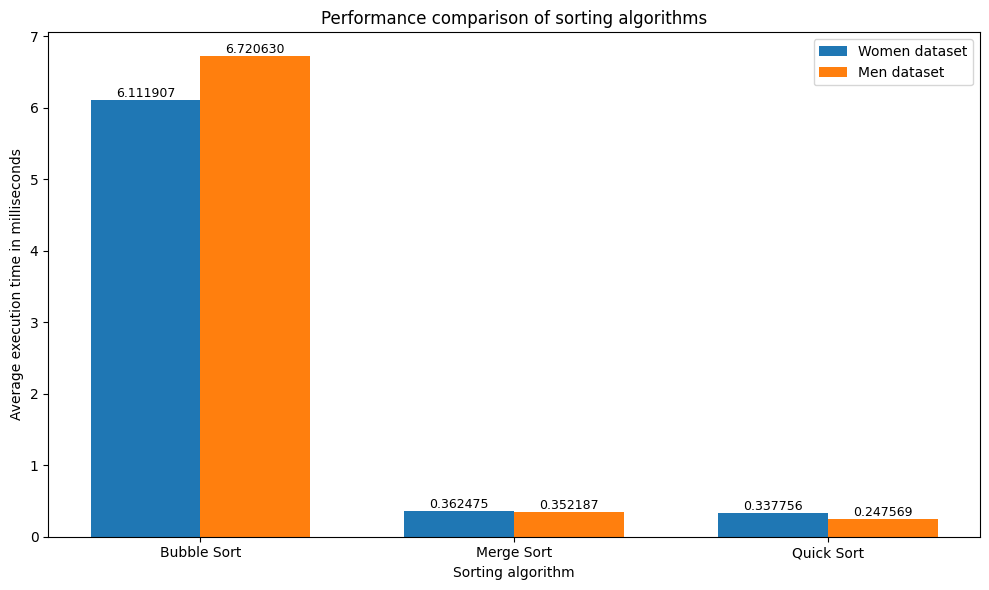

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a table with all performance results
comparison_results = pd.DataFrame({
    "Algorithm": [
        "Bubble Sort",
        "Merge Sort",
        "Quick Sort"
    ],
    "Women dataset (ms)": [
        bubble_average_ms,
        merge_average_ms,
        quick_women_average_ms
    ],
    "Men dataset (ms)": [
        bubble_men_average_ms,
        merge_men_average_ms,
        quick_men_average_ms
    ]
})

# Show the results as a table
display(comparison_results.round(6))

# Create positions for the bars
x_positions = np.arange(
    len(comparison_results["Algorithm"])
)

bar_width = 0.35

# Create the grouped bar chart
plt.figure(figsize=(10, 6))

women_bars = plt.bar(
    x_positions - bar_width / 2,
    comparison_results["Women dataset (ms)"],
    width=bar_width,
    label="Women dataset"
)

men_bars = plt.bar(
    x_positions + bar_width / 2,
    comparison_results["Men dataset (ms)"],
    width=bar_width,
    label="Men dataset"
)

# Add titles and labels
plt.title("Performance comparison of sorting algorithms")
plt.xlabel("Sorting algorithm")
plt.ylabel("Average execution time in milliseconds")

plt.xticks(
    x_positions,
    comparison_results["Algorithm"]
)

plt.legend()

# Show the execution time above each bar
for bars in [women_bars, men_bars]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.6f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

## Conclusion

All three sorting algorithms worked correctly on both datasets.

The table and graph show the execution time for Bubble Sort, Merge Sort and Quick Sort.

The fastest algorithm is the algorithm with the lowest average execution time.

The results show that the choice of sorting algorithm affects code performance.

Because the datasets now contain data from multiple countries and years, the differences between the algorithms are easier to study.


# Milestone 4
## 12. Functions and object-oriented programming

In this milestone, We will create functions and classes that can be used for a gender equality application.

A function is a reusable block of code. It receives information, performs an operation and returns a result.

The first function calculates the average `OBS_VALUE` of a dataset. This can be used to quickly summarize a group, such as women or men.

### Note to self: What is a function?

A function is a reusable block of code.

It can:

- receive information;
- perform an action;
- return a result.

You write a function once. After that, you can use it many times with different data.

For example, the same function can calculate the average for the women’s dataset and the men’s dataset.

Functions make code shorter, clearer and easier to reuse.

In [19]:
def calculate_average(records, key="OBS_VALUE"):
    # Get all valid numerical values
    values = [
        record[key]
        for record in records
        if record.get(key) is not None
    ]

    # Return None when the dataset contains no values
    if len(values) == 0:
        return None

    # Calculate and return the average
    average = sum(values) / len(values)

    return average

In [20]:
# Calculate the average for the women's dataset
women_average = calculate_average(
    women_records
)

# Calculate the average for the men's dataset
men_average = calculate_average(
    men_records
)

print(
    f"Average OBS_VALUE for women: "
    f"{women_average:.2f}"
)

print(
    f"Average OBS_VALUE for men: "
    f"{men_average:.2f}"
)

Average OBS_VALUE for women: 75.69
Average OBS_VALUE for men: 84.58


## Conclusion

The function worked correctly for both datasets.

The output shows the average `OBS_VALUE` for women and men.

Both averages are based on the same indicator, age group, countries, unit and years.

This means that the comparison is more meaningful than a comparison that mixes different indicators.

This example also shows that the same function can be reused for different datasets.


## 13. Function 2: Filter records by a minimum value

The second function filters the dataset.

It keeps only the records where `OBS_VALUE` is equal to or higher than a chosen minimum value.

This can be useful when we want to study only high percentages or identify records that reach a specific target.

In [21]:
def filter_by_minimum_value(
    records,
    minimum_value,
    key="OBS_VALUE"
):
    # Create an empty list for the filtered records
    filtered_records = []

    # Check every record in the dataset
    for record in records:
        value = record.get(key)

        # Keep the record when the value meets the minimum
        if value is not None and value >= minimum_value:
            filtered_records.append(record)

    return filtered_records

In [22]:
# Filter the women's dataset
high_values_women = filter_by_minimum_value(
    women_records,
    minimum_value=80
)

# Filter the men's dataset
high_values_men = filter_by_minimum_value(
    men_records,
    minimum_value=80
)

print(
    f"Women's records with OBS_VALUE of 80 or higher: "
    f"{len(high_values_women)}"
)

print(
    f"Men's records with OBS_VALUE of 80 or higher: "
    f"{len(high_values_men)}"
)

Women's records with OBS_VALUE of 80 or higher: 160
Men's records with OBS_VALUE of 80 or higher: 478


In [23]:
print("First five results for women:")

for record in high_values_women[:5]:
    print(
        record["TIME"],
        record["OBS_VALUE"]
    )

print("\nFirst five results for men:")

for record in high_values_men[:5]:
    print(
        record["TIME"],
        record["OBS_VALUE"]
    )

First five results for women:
Q2-2019 81.5
Q2-2021 81.8
Q1-2020 81.9
Q1-2022 82.9
Q3-2021 82.3

First five results for men:
Q2-2022 90.5
Q4-2015 88.0
Q1-2017 88.4
Q4-2022 90.5
Q2-2021 89.7


## Conclusion

The filter function worked correctly for both datasets.

The output shows how many records have an `OBS_VALUE` of `80` or higher.

All records use the same indicator and unit, so the minimum value has the same meaning throughout the datasets.

The function can be reused with other groups and other minimum values.


## 14. Function 3: Calculate the difference between two groups

This function compares the average value of two groups.

First, it calculates the average for each group. After that, it subtracts the second average from the first average.

A positive result means that the first group has a higher average.

A negative result means that the first group has a lower average.

This can be useful for finding differences between women and men.

In [24]:
def calculate_group_difference(
    first_group,
    second_group,
    key="OBS_VALUE"
):
    # Calculate the average for both groups
    first_average = calculate_average(
        first_group,
        key
    )

    second_average = calculate_average(
        second_group,
        key
    )

    # Return None when one group has no valid values
    if first_average is None or second_average is None:
        return None

    # Calculate the difference
    difference = first_average - second_average

    return difference


In [25]:
# Calculate the difference between women and men
overall_difference = calculate_group_difference(
    women_records,
    men_records
)

print(
    f"Difference between the women's and men's average: "
    f"{overall_difference:.2f}"
)

Difference between the women's and men's average: -8.89


In [26]:
# Compare the filtered datasets
high_value_difference = calculate_group_difference(
    high_values_women,
    high_values_men
)

print(
    f"Difference for records with OBS_VALUE of 80 or higher: "
    f"{high_value_difference:.2f}"
)

Difference for records with OBS_VALUE of 80 or higher: -3.98


## Conclusion

The function worked correctly.

The first result compares the average value for women and men across all selected records.

The second result compares only records with an `OBS_VALUE` of `80` or higher.

A negative result means that the women's average is lower. A positive result means that the women's average is higher.

Because both groups use the same countries, indicator, unit and years, the differences can be compared more clearly.


### Note to self: What are classes and instances?

A class is a plan for creating objects.

The class describes:

- what information an object stores;
- what actions the object can perform.

An instance is one object created from a class.

For example, we can create a `GenderDataset` class.

From this class, we can create:

- one instance for the women’s dataset;
- one instance for the men’s dataset.

Both instances use the same class, but they contain different data.

## 14. Class 1: GenderDataset

The `GenderDataset` class represents one gender dataset.

Each instance stores:

- the name of the group;
- the records of the group.

The class also has methods.

A method is a function inside a class.

The methods calculate the average value and count records above a minimum value.

In [27]:
class GenderDataset:
    # This method runs when a new instance is created
    def __init__(self, name, records):
        self.name = name
        self.records = records

    # Calculate the average OBS_VALUE
    def get_average(self):
        return calculate_average(
            self.records,
            key="OBS_VALUE"
        )

    # Count records that meet a minimum value
    def count_above(self, minimum_value):
        filtered_records = filter_by_minimum_value(
            self.records,
            minimum_value,
            key="OBS_VALUE"
        )

        return len(filtered_records)

In [28]:
# Create an instance for the women's dataset
women_dataset = GenderDataset(
    name="Women",
    records=women_records
)

# Create an instance for the men's dataset
men_dataset = GenderDataset(
    name="Men",
    records=men_records
)

In [29]:
# Use two methods for the women's instance
print(
    f"{women_dataset.name} average: "
    f"{women_dataset.get_average():.2f}"
)

print(
    f"{women_dataset.name} records of 80 or higher: "
    f"{women_dataset.count_above(80)}"
)

print()

# Use two methods for the men's instance
print(
    f"{men_dataset.name} average: "
    f"{men_dataset.get_average():.2f}"
)

print(
    f"{men_dataset.name} records of 80 or higher: "
    f"{men_dataset.count_above(80)}"
)

Women average: 75.69
Women records of 80 or higher: 160

Men average: 84.58
Men records of 80 or higher: 478


## Conclusion

The `GenderDataset` class worked correctly.

Two instances were created:

- one instance for women;
- one instance for men.

Both instances use the same methods to calculate an average and count records with an `OBS_VALUE` of `80` or higher.

The two datasets contain the same type of information, but store records for different groups.

This example shows that one class can be used to create different objects with comparable data.


## 15. Class 2: GroupComparison

The `GroupComparison` class compares two datasets.

Each instance stores:

- the name of the first group;
- the records of the first group;
- the name of the second group;
- the records of the second group.

The class calculates the difference between the average values of both groups.

A negative result means that the first group has a lower average.

A positive result means that the first group has a higher average.

In [30]:
class GroupComparison:
    # This method runs when a new instance is created
    def __init__(
        self,
        first_name,
        first_records,
        second_name,
        second_records
    ):
        self.first_name = first_name
        self.first_records = first_records
        self.second_name = second_name
        self.second_records = second_records

    # Calculate the difference between both averages
    def get_difference(self):
        return calculate_group_difference(
            self.first_records,
            self.second_records,
            key="OBS_VALUE"
        )

    # Create a simple explanation of the result
    def describe_difference(self):
        difference = self.get_difference()

        if difference is None:
            return "The difference could not be calculated."

        if difference < 0:
            return (
                f"{self.first_name} have an average value that is "
                f"{abs(difference):.2f} points lower than "
                f"{self.second_name}."
            )

        if difference > 0:
            return (
                f"{self.first_name} have an average value that is "
                f"{difference:.2f} points higher than "
                f"{self.second_name}."
            )

        return (
            f"{self.first_name} and {self.second_name} "
            f"have the same average value."
        )

In [31]:
# Compare all records
overall_comparison = GroupComparison(
    first_name="Women",
    first_records=women_records,
    second_name="men",
    second_records=men_records
)

# Compare only records with an OBS_VALUE of 80 or higher
high_value_comparison = GroupComparison(
    first_name="Women",
    first_records=high_values_women,
    second_name="men",
    second_records=high_values_men
)

In [32]:
# Use the first instance
print("Overall comparison:")
print(
    f"Difference: "
    f"{overall_comparison.get_difference():.2f}"
)
print(overall_comparison.describe_difference())

print()

# Use the second instance
print("Comparison of values of 80 or higher:")
print(
    f"Difference: "
    f"{high_value_comparison.get_difference():.2f}"
)
print(high_value_comparison.describe_difference())

Overall comparison:
Difference: -8.89
Women have an average value that is 8.89 points lower than men.

Comparison of values of 80 or higher:
Difference: -3.98
Women have an average value that is 3.98 points lower than men.


## Conclusion

The `GroupComparison` class worked correctly.

Two instances were created:

- one instance for all selected records;
- one instance for records with an `OBS_VALUE` of 80 or higher.

The output explains whether the women's average is higher or lower than the men's average.

Because the datasets use the same selection rules, the class compares similar records from both groups.


## 16. Class 3: ThresholdAnalysis

The `ThresholdAnalysis` class checks how many records reach a chosen minimum value.

Each instance stores:

- the name of the group;
- the records of the group;
- the minimum value.

The class can calculate the number and percentage of records that reach the minimum value.

In [33]:
class ThresholdAnalysis:
    # This method runs when a new instance is created
    def __init__(
        self,
        group_name,
        records,
        minimum_value
    ):
        self.group_name = group_name
        self.records = records
        self.minimum_value = minimum_value

    # Find the records that reach the minimum value
    def get_matching_records(self):
        return filter_by_minimum_value(
            self.records,
            self.minimum_value,
            key="OBS_VALUE"
        )

    # Count the matching records
    def get_count(self):
        return len(self.get_matching_records())

    # Calculate the percentage of matching records
    def get_percentage(self):
        if len(self.records) == 0:
            return 0

        percentage = (
            self.get_count() / len(self.records)
        ) * 100

        return percentage

    # Create a simple explanation
    def describe_result(self):
        return (
            f"{self.group_name}: {self.get_count()} of "
            f"{len(self.records)} records have an OBS_VALUE of "
            f"{self.minimum_value} or higher. "
            f"This is {self.get_percentage():.2f}%."
        )

In [34]:
# Create an instance for women
women_threshold_analysis = ThresholdAnalysis(
    group_name="Women",
    records=women_records,
    minimum_value=80
)

# Create an instance for men
men_threshold_analysis = ThresholdAnalysis(
    group_name="Men",
    records=men_records,
    minimum_value=80
)

In [35]:
# Use the women's instance
print(women_threshold_analysis.describe_result())

print(
    f"Percentage for women: "
    f"{women_threshold_analysis.get_percentage():.2f}%"
)

print()

# Use the men's instance
print(men_threshold_analysis.describe_result())

print(
    f"Percentage for men: "
    f"{men_threshold_analysis.get_percentage():.2f}%"
)

Women: 160 of 540 records have an OBS_VALUE of 80 or higher. This is 29.63%.
Percentage for women: 29.63%

Men: 478 of 540 records have an OBS_VALUE of 80 or higher. This is 88.52%.
Percentage for men: 88.52%


## Conclusion

The `ThresholdAnalysis` class worked correctly.

Two instances were created:

- one for women;
- one for men.

The output shows the number and percentage of records with an `OBS_VALUE` of `80` or higher.

Both instances use the same indicator, unit, countries and years.

This means that the threshold results can be compared between the two groups.

The class can be reused with other groups and other minimum values.


# Final conclusion

In this milestone, I created three functions and three classes for working with gender equality data.

The functions can:

- calculate an average value;
- filter records using a minimum value;
- calculate the difference between two groups.

The classes can:

- store and analyse a gender dataset;
- compare two groups;
- analyse how many records reach a chosen minimum value.

Each class was used to create at least two instances. The examples used separate objects for women, men and different types of comparisons.

The results show that functions and classes make code easier to reuse. The same code can work with different datasets without writing everything again.

This code could be used as a starting point for a larger gender equality application.

# Milestone 5

# Data structures for a gender equality application

A data structure is a way to organize and store information in Python.

Different data structures are useful for different types of information.

| Information | Data structure | Use in an application |
|---|---|---|
| A collection of `OBS_VALUE` values | List | A list can store all values in order. The application can use this list to calculate averages, sort values or create graphs. |
| All information from one observation | Dictionary | A dictionary connects labels such as `TIME`, `SEX` and `OBS_VALUE` to their values. This makes one record easy to understand and access. |
| The average value for each gender | Dictionary | The gender can be the key and the average can be the value. This makes it easy to compare women and men. |
| Unique years in the dataset | Set | A set stores every year only once. This helps the application show which years are available. |
| A fixed combination of country and gender | Tuple | A tuple can store information such as `("NLD", "WOMEN")`. It is useful when the values should not change. |
| Values grouped by year and gender | Nested dictionary | A nested dictionary can organize values first by year and then by gender. This can be used for comparisons and dashboard filters. |

### Note to self: 

## Lists

A list is useful when we want to store multiple items in one variable.

Lists keep their order and can contain duplicate values.

In this application, a list can store all observation values. We can then calculate results, sort the values or display them in a graph.

## Dictionaries

A dictionary stores information as key-value pairs.

For example, the key can be `"gender"` and the value can be `"women"`.

Dictionaries are useful when every value needs a clear label. They can also connect a group, year or country to a calculated result.

## Sets

A set stores unique values.

Duplicate values are automatically removed.

In this application, a set can be used to find all unique years, countries or age groups in the dataset.

## Tuples

A tuple stores multiple values in a fixed order.

A tuple cannot be changed after it is created.

This can be useful for fixed combinations, such as a country code and gender.

## 16. Data structure 1: List

A list stores multiple values in one variable.

A list keeps the order of the values and can contain duplicate values.

In this example, we create one list with the `OBS_VALUE` values for women and one list for men.

These lists can be used to calculate averages, find minimum and maximum values, sort the data or create graphs.

In [36]:
# Create a list with all OBS_VALUE values for women
women_values_list = [
    record["OBS_VALUE"]
    for record in women_records
]

# Create a list with all OBS_VALUE values for men
men_values_list = [
    record["OBS_VALUE"]
    for record in men_records
]

# Show information about both lists
print(f"Number of values for women: {len(women_values_list)}")
print(f"First five values for women: {women_values_list[:5]}")

print()

print(f"Number of values for men: {len(men_values_list)}")
print(f"First five values for men: {men_values_list[:5]}")

Number of values for women: 540
First five values for women: [78.5, 81.5, 77.4, 78.4, 76.7]

Number of values for men: 540
First five values for men: [90.5, 88.0, 88.4, 90.5, 89.7]


In [37]:
# Calculate simple results from the women's list
print("Women:")
print(f"Lowest value: {min(women_values_list)}")
print(f"Highest value: {max(women_values_list)}")
print(f"Average value: {sum(women_values_list) / len(women_values_list):.2f}")

print()

# Calculate simple results from the men's list
print("Men:")
print(f"Lowest value: {min(men_values_list)}")
print(f"Highest value: {max(men_values_list)}")
print(f"Average value: {sum(men_values_list) / len(men_values_list):.2f}")

Women:
Lowest value: 57.2
Highest value: 85.1
Average value: 75.69

Men:
Lowest value: 70.1
Highest value: 90.6
Average value: 84.58


## Conclusion

The lists worked correctly.

Both lists contain values from the selected gender equality data.

The output shows:

- the number of values;
- the lowest value;
- the highest value;
- the average value.

The women and men lists use the same indicator, unit, countries and years.

This example shows that lists are useful for storing many comparable values and calculating simple results.
